## 1️⃣ Importar librerías y definir funciones auxiliares
Importamos las librerías necesarias y definimos funciones para cargar datos, aplicar time shift, detectar plateaus y realizar fits.

In [1]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot

# Función para cargar datos ROOT (adaptar a tu estructura de árbol)
def cargar_datos_root(filepath):
    file = uproot.open(filepath)
    peak_data = file["peak"].arrays(library="np")
    temp_data = file["temp"].arrays(library="np")
    press_data = file["press"].arrays(library="np")
    return peak_data, temp_data, press_data

# Función para aplicar time shift a un array de timestamps
def aplicar_time_shift(times, shift_horas):
    return np.array([t + datetime.timedelta(hours=shift_horas) for t in times])

# Función para filtrar y detectar plateaus (provisional, editable)
def seleccionar_plateaus(tiempos, intervalos):
    # intervalos: lista de tuplas (t_ini, t_fin)
    masks = [(tiempos >= t_ini) & (tiempos <= t_fin) for t_ini, t_fin in intervalos]
    return masks

# Función para ajustar (fit) linealmente cada plateau
def fit_plateau(x, y):
    mask = ~np.isnan(x) & ~np.isnan(y)
    if np.sum(mask) < 2:
        return np.nan, np.nan
    slope, intercept, r_value, p_value, std_err = stats.linregress(x[mask], y[mask])
    return slope, std_err


# Análisis FBG: PEEK-1 (450μm) – 4 días (25-09-24, 26-09-24, 30-09-24, 01-10-24)

Este notebook analiza los archivos de la fibra PEEK-1 (450μm) correspondientes a las fechas indicadas. El objetivo es detectar plateaus, realizar fits y analizar la repetibilidad de las sensibilidades. El flujo sigue el estilo del notebook de DW-3 (11-02-26), pero está simplificado para depuración y comparación rápida.

**Pasos principales:**
1. Importar librerías y definir funciones auxiliares
2. Cargar y visualizar datos de los cuatro archivos
3. Aplicar time shift y preprocesamiento
4. Visualización superpuesta de 'wav' y 'temp' vs tiempo
5. Selección provisional de plateaus (editable)
6. Detección y ajuste (fit) de plateaus
7. Cálculo de sensibilidad
8. Plot de repetibilidad de sensibilidades
9. Tabla resumen de sensibilidades

> ⚠️ Los intervalos de plateaus son provisionales y deben editarse manualmente según inspección visual.


## 2️⃣ Cargar y visualizar datos de los cuatro archivos
Cargamos los archivos ROOT de los días 25-09-24, 26-09-24, 30-09-24 y 01-10-24. Mostramos información básica de cada uno.

In [2]:
# Rutas a los archivos ROOT (ajusta las rutas reales)
archivos = {
    '2024-09-25': '/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20240925.root',
    '2024-09-26': '/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20240926.root',
    '2024-09-30': '/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20240930.root',
    '2024-10-01': '/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20241001.root',
}

datos = {}
for fecha, ruta in archivos.items():
    try:
        peak, temp, press = cargar_datos_root(ruta)
        datos[fecha] = {'peak': peak, 'temp': temp, 'press': press}
        print(f"✅ {fecha}: {ruta}")
        print(f"   peak keys: {list(peak.keys())}")
        print(f"   temp keys: {list(temp.keys())}")
        print(f"   press keys: {list(press.keys())}")
        print(f"   peak shape: {peak['wav'].shape if 'wav' in peak else 'N/A'}")
        print(f"   temp shape: {temp['temp'].shape if 'temp' in temp else 'N/A'}")
        print(f"   press shape: {press['press'].shape if 'press' in press else 'N/A'}")
        # Comprobar si hay datos válidos en wav
        if 'wav' in peak and peak['wav'].size > 0:
            print(f"   Primeros 5 tiempos de picos: {peak['t'][:5,0] if 't' in peak and peak['t'].ndim>1 else peak['t'][:5] if 't' in peak else 'N/A'}")
            if fecha == '2024-09-25':
                print(f"   Primeros 5 valores de longitud de onda (nm, sin escalar): {peak['wav'][:5]}")
        else:
            print("   No hay datos válidos de picos (wav)")
        if 'temp' in temp and temp['temp'].size > 0:
            print(f"   Primeros 5 tiempos de temp: {temp['t'][:5] if 't' in temp else 'N/A'}")
    except Exception as e:
        print(f"❌ Error cargando {fecha}: {e}")

✅ 2024-09-25: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20240925.root
   peak keys: ['t', 'wav', 'sweep', 'ch', 'pos']
   temp keys: ['t', 'temp']
   press keys: ['t', 'press']
   peak shape: (1567500, 2, 1)
   temp shape: (6806, 8)
   press shape: (15670, 1)
   Primeros 5 tiempos de picos: [9.46684854e+08 9.46684854e+08 9.46684854e+08 9.46684854e+08
 9.46684854e+08]
   Primeros 5 valores de longitud de onda (nm, sin escalar): [[[1.56011581e-06]
  [1.56012061e-06]]

 [[1.56011588e-06]
  [1.56012087e-06]]

 [[1.56011590e-06]
  [1.56011980e-06]]

 [[1.56011516e-06]
  [1.56012033e-06]]

 [[1.56011530e-06]
  [1.56011981e-06]]]
   Primeros 5 tiempos de temp: [1.72726531e+09 1.72726531e+09 1.72726532e+09 1.72726532e+09
 1.72726532e+09]
✅ 2024-09-26: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20240926.root
   peak keys: ['t', 'wav', 'sweep', 'ch', 'pos']
   temp keys: ['t', 'temp']
   press keys: ['t', 'press']
   peak shape: (1624750, 2, 1)
   temp shape: (7143, 8)
   

## 3️⃣ Aplicar time shift y preprocesamiento
Aplicamos el time shift necesario a los datos de cada archivo y realizamos preprocesamiento básico.

In [3]:
# Configura aquí el time shift (en horas) para cada archivo si es necesario
# Por defecto, 0 horas. Ajusta según diagnóstico visual posterior.
time_shifts = {
    '2024-09-25': 0,  # Se ajustará manualmente para este run
    '2024-09-26': 4,
    '2024-09-30': 4,
    '2024-10-01': 4,
}

for fecha in datos:
    peak = datos[fecha]['peak']
    temp = datos[fecha]['temp']
    press = datos[fecha]['press']
    # Convertir tiempos a datetime
    if fecha == '2024-09-25':
        # Forzar alineación: usar los tiempos de temperatura para los picos
        times_peak = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in temp['t']])
        print("Alineando tiempos de picos con los de temperatura para 25-09-2024")
        # Corregir shape de wav si es necesario
        wav = peak['wav']
        if wav.ndim == 3:
            print(f"Corrigiendo shape de wav de {wav.shape} a {(wav.shape[0], wav.shape[1])}")
            wav = wav[:, :, 0]
        wav = wav * 1e9  # m -> nm
    else:
        times_peak = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in peak['t'][:,0]])
        wav = peak['wav'] * 1e9  # m -> nm
    # --- Robustez: asegurar wav es float64 y 2D (N,2) ---
    wav = np.asarray(wav)
    if wav.ndim == 1:
        wav = wav[:, np.newaxis]
    elif wav.ndim == 3 and wav.shape[2] == 1:
        wav = wav[:,:,0]
    if wav.ndim == 2 and wav.shape[1] > 2:
        wav = wav[:,:2]  # Solo las dos primeras polarizaciones
    wav = wav.astype(float)
    times_temp = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in temp['t']])
    times_press = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in press['t']])
    # Aplicar time shift a wavelength
    times_peak_shifted = aplicar_time_shift(times_peak, time_shifts[fecha])
    datos[fecha]['times_peak'] = times_peak_shifted
    datos[fecha]['times_temp'] = times_temp
    datos[fecha]['times_press'] = times_press
    # Guardar también los datos de wav, temp, press
    # Filtrado: solo positivos y outliers (μ±3σ) para cada polarización
    wav_filtrado = np.zeros_like(wav)
    for idx_pol in range(wav.shape[1]):
        wav_pol = wav[:, idx_pol]
        mask_pos = wav_pol > 0
        wav_pos = wav_pol[mask_pos]
        if len(wav_pos) > 0:
            mu = np.mean(wav_pos)
            sigma = np.std(wav_pos)
            mask_out = (wav_pol > mu - 3*sigma) & (wav_pol < mu + 3*sigma)
            wav_filtrado[:, idx_pol] = np.where(mask_pos & mask_out, wav_pol, np.nan)
        else:
            wav_filtrado[:, idx_pol] = np.nan
    datos[fecha]['wav'] = wav_filtrado.astype(float)
    datos[fecha]['temp_val'] = temp['temp']
    datos[fecha]['press_val'] = press['press']


Alineando tiempos de picos con los de temperatura para 25-09-2024
Corrigiendo shape de wav de (1567500, 2, 1) a (1567500, 2)


# 4️⃣ Visualización superpuesta de 'wav' y 'temp' vs tiempo (para cada archivo)
Graficamos 'wav' y 'temp' superpuestos en función del tiempo para cada archivo, para inspección visual y debug.

Alineando longitud de onda y tiempos para 2024-09-25: cortando a 6806 muestras


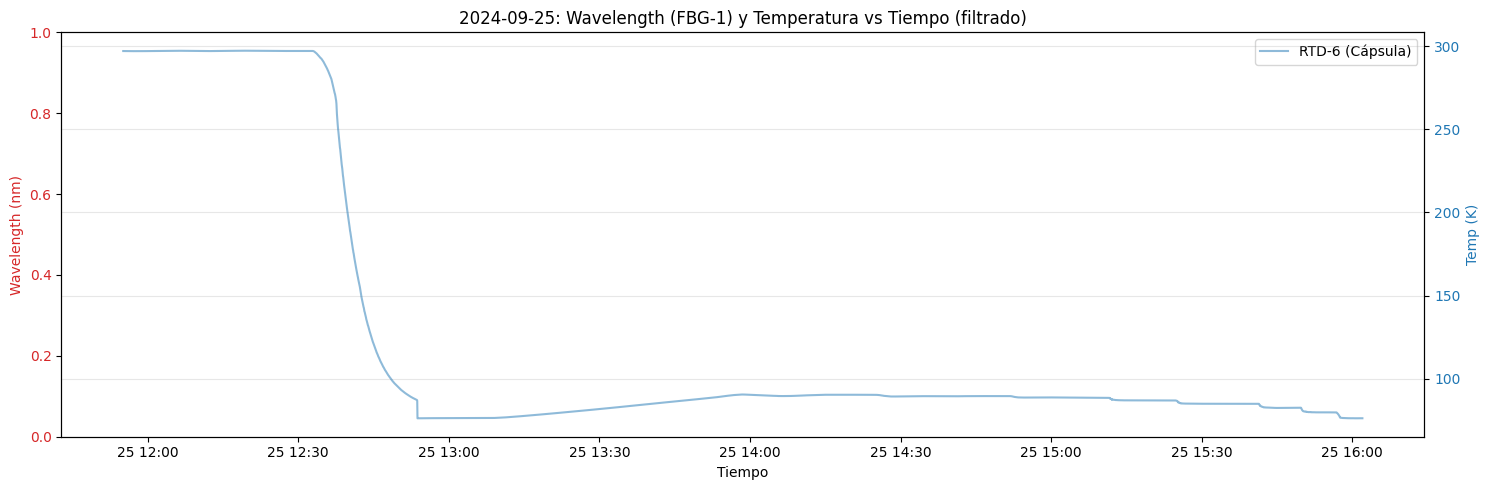

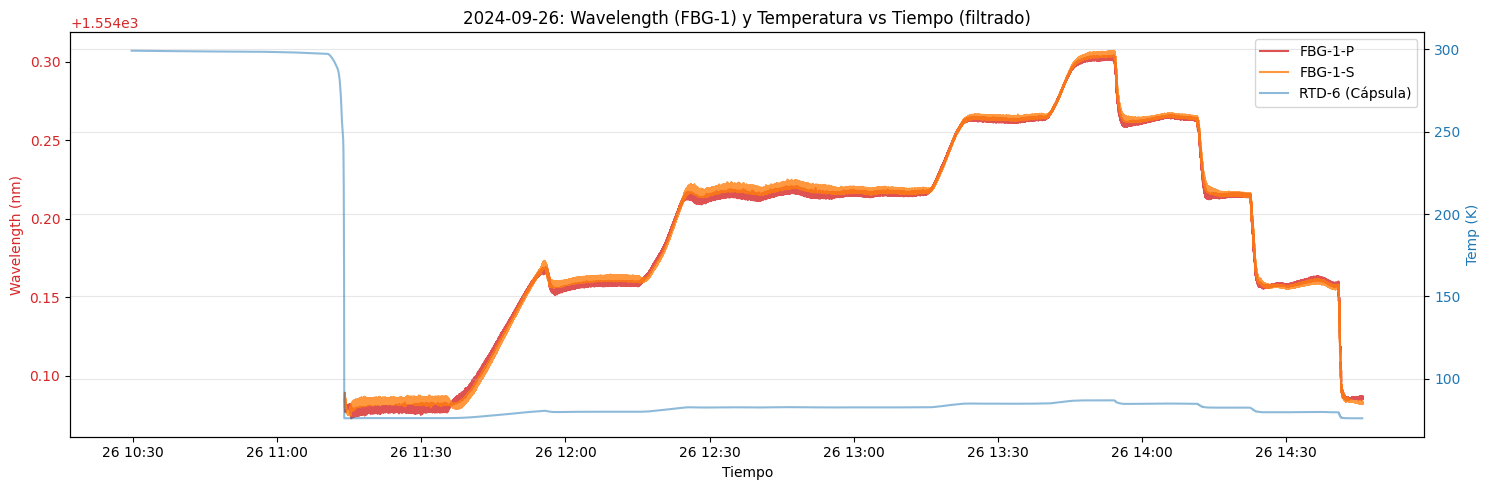

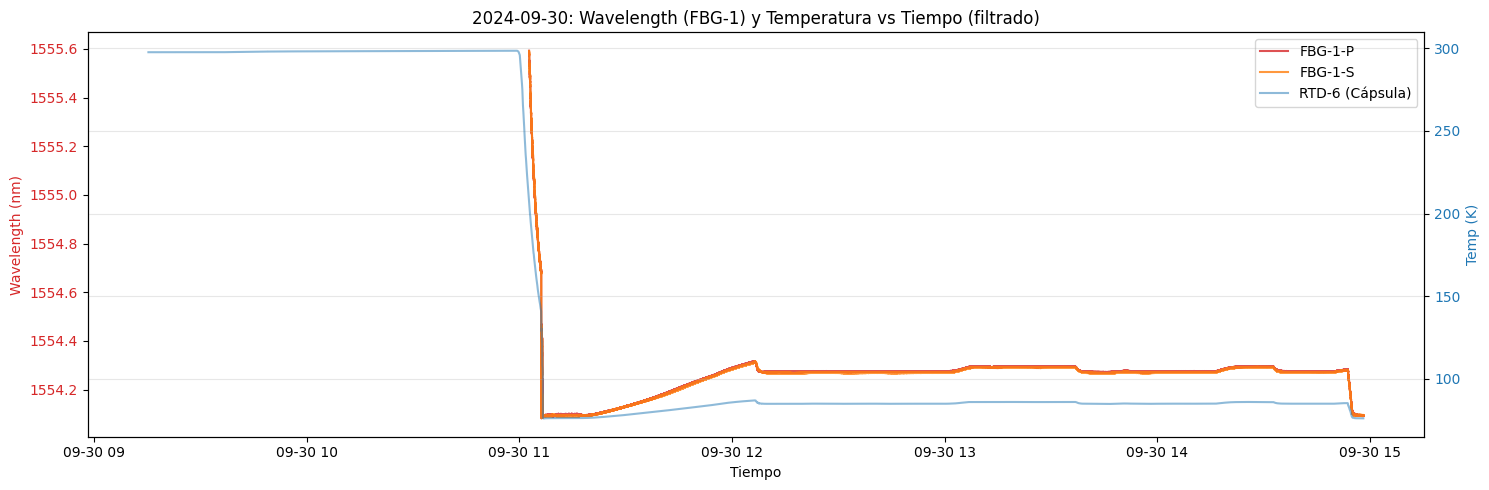

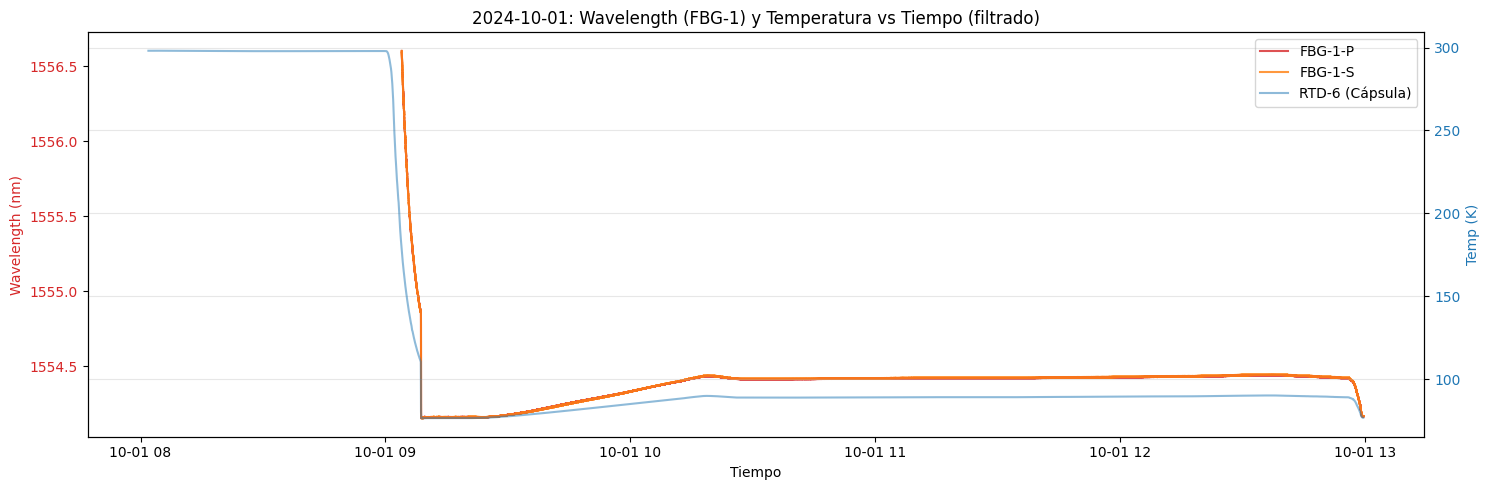

In [4]:
# Visualización para cada archivo: 'wav' (ambas polarizaciones) y 'temp' (RTD cápsula)
# Eje izquierdo: longitud de onda (nm), eje derecho: temperatura (K)
for fecha in datos:
    fig, ax1 = plt.subplots(figsize=(15,5))
    wav = datos[fecha]['wav']
    times = np.array(datos[fecha]['times_peak'])
    temp = datos[fecha]['temp_val']
    times_temp = datos[fecha]['times_temp']
    # --- CORRECCIÓN PARA 25-09-2024: asegurar alineación de longitud de onda y tiempo ---
    if fecha == '2024-09-25':
        # Si wav y times tienen diferente longitud, recortar ambos al mínimo común
        min_len = min(len(times), wav.shape[0])
        if len(times) != wav.shape[0]:
            print(f"Alineando longitud de onda y tiempos para {fecha}: cortando a {min_len} muestras")
        times = times[:min_len]
        wav = wav[:min_len]
    # Asegurarse de que wav es 2D y times es 1D
    if wav.ndim == 1:
        wav = wav[:, np.newaxis]
    elif wav.ndim > 2:
        wav = wav.reshape(wav.shape[0], -1)
    if times.ndim > 1:
        times = times.flatten()
    # Comprobar dimensiones
    shape = wav.shape
    if len(shape) == 2:
        n_samples, n_pols = shape
    elif len(shape) == 1:
        n_samples = shape[0]
        n_pols = 1
        wav = wav[:, np.newaxis]
    else:
        raise ValueError(f"Forma inesperada de wav: {shape}")
    pol_labels = ['P', 'S']
    colors = ['tab:red', 'tab:orange']
    for idx_pol in range(n_pols):
        pol = pol_labels[idx_pol] if idx_pol < len(pol_labels) else f'Pol{idx_pol}'
        wav_pol = wav[:, idx_pol]
        mask_valid = ~np.isnan(wav_pol)
        # Solo graficar si hay datos válidos y dimensiones coinciden
        if np.sum(mask_valid) > 0 and len(times) == len(wav_pol):
            ax1.plot(times[mask_valid], wav_pol[mask_valid], label=f'FBG-1-{pol}', color=colors[idx_pol%len(colors)], alpha=0.8)
    ax1.set_xlabel('Tiempo')
    ax1.set_ylabel('Wavelength (nm)', color='tab:red')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    # Eje derecho para temperatura
    if temp.ndim == 2 and temp.shape[1] > 6:
        ax2 = ax1.twinx()
        ax2.plot(times_temp, temp[:,6], label='RTD-6 (Cápsula)', color='tab:blue', alpha=0.5)
        ax2.set_ylabel('Temp (K)', color='tab:blue')
        ax2.tick_params(axis='y', labelcolor='tab:blue')
    # Leyenda combinada
    lines, labels = ax1.get_legend_handles_labels()
    if temp.ndim == 2 and temp.shape[1] > 6:
        lines2, labels2 = ax2.get_legend_handles_labels()
        lines += lines2
        labels += labels2
    ax1.legend(lines, labels, loc='best')
    plt.title(f"{fecha}: Wavelength (FBG-1) y Temperatura vs Tiempo (filtrado)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

wav_orig shape: (1567500, 2, 1)
times_temp shape: (6806,)
Pol P: 6806 valores > 0 de 6806
Pol S: 6806 valores > 0 de 6806


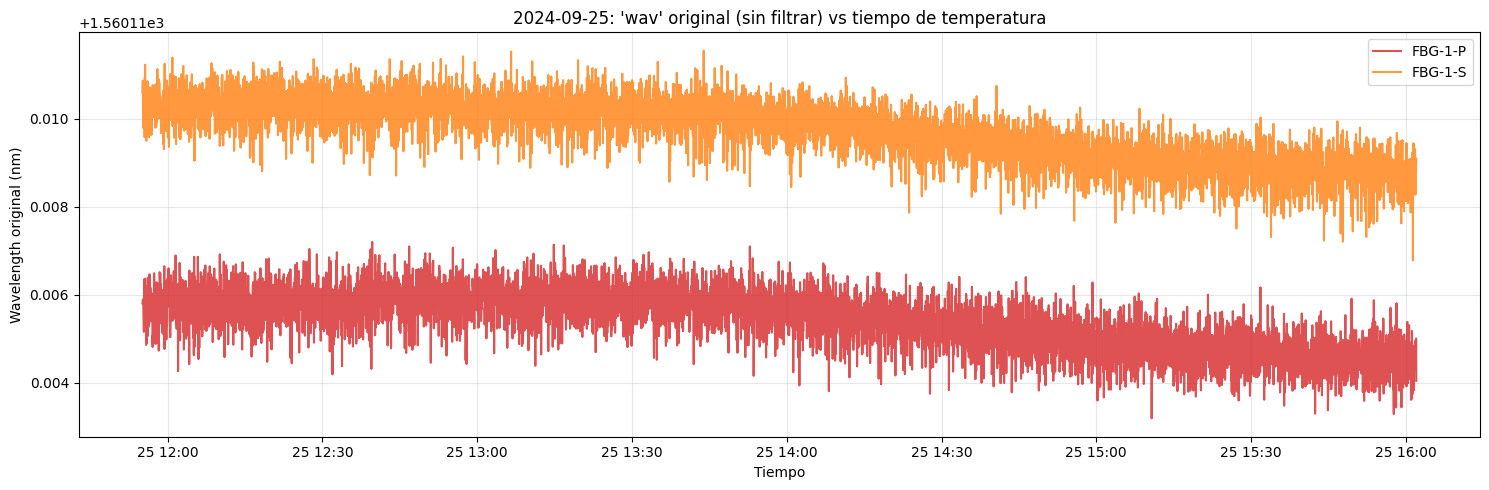

In [5]:
# Diagnóstico: graficar los primeros valores válidos originales de 'wav' frente a los tiempos de temperatura para el día 25-09-2024
fecha = '2024-09-25'
if fecha in datos:
    peak = datos[fecha]['peak']
    temp = datos[fecha]['temp']
    # Extraer los datos originales (sin filtrar ni escalar)
    wav_orig = peak['wav']
    times_temp = temp['t']
    print(f"wav_orig shape: {wav_orig.shape}")
    print(f"times_temp shape: {times_temp.shape}")
    # Si wav_orig es 3D, reducir a 2D (N,2)
    if wav_orig.ndim == 3 and wav_orig.shape[2] == 1:
        wav_orig = wav_orig[:,:,0]
    # Escalar a nm
    wav_orig_nm = wav_orig * 1e9
    # Alinear: usar solo los primeros N puntos donde N = min(len(times_temp), wav_orig.shape[0])
    min_len = min(len(times_temp), wav_orig_nm.shape[0])
    wav_plot = wav_orig_nm[:min_len]
    times_plot = times_temp[:min_len]
    # Convertir tiempos a datetime
    times_plot_dt = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_plot])
    pol_labels = ['P', 'S']
    colors = ['tab:red', 'tab:orange']
    fig, ax = plt.subplots(figsize=(15,5))
    for idx_pol in range(wav_plot.shape[1]):
        pol = pol_labels[idx_pol] if idx_pol < len(pol_labels) else f'Pol{idx_pol}'
        wav_pol = wav_plot[:, idx_pol]
        mask_valid = wav_pol > 0
        print(f"Pol {pol}: {np.sum(mask_valid)} valores > 0 de {len(wav_pol)}")
        if np.sum(mask_valid) > 0:
            ax.plot(times_plot_dt[mask_valid], wav_pol[mask_valid], label=f'FBG-1-{pol}', color=colors[idx_pol%len(colors)], alpha=0.8)
    ax.set_xlabel('Tiempo')
    ax.set_ylabel('Wavelength original (nm)')
    ax.legend()
    plt.title(f"{fecha}: 'wav' original (sin filtrar) vs tiempo de temperatura")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"No hay datos para {fecha}")


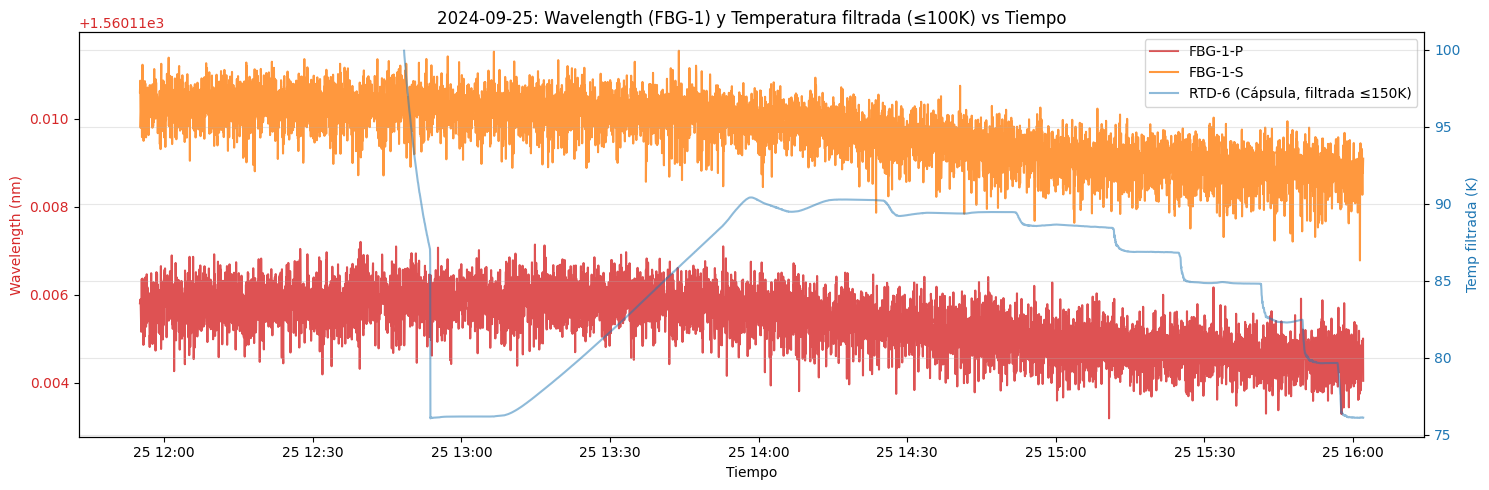

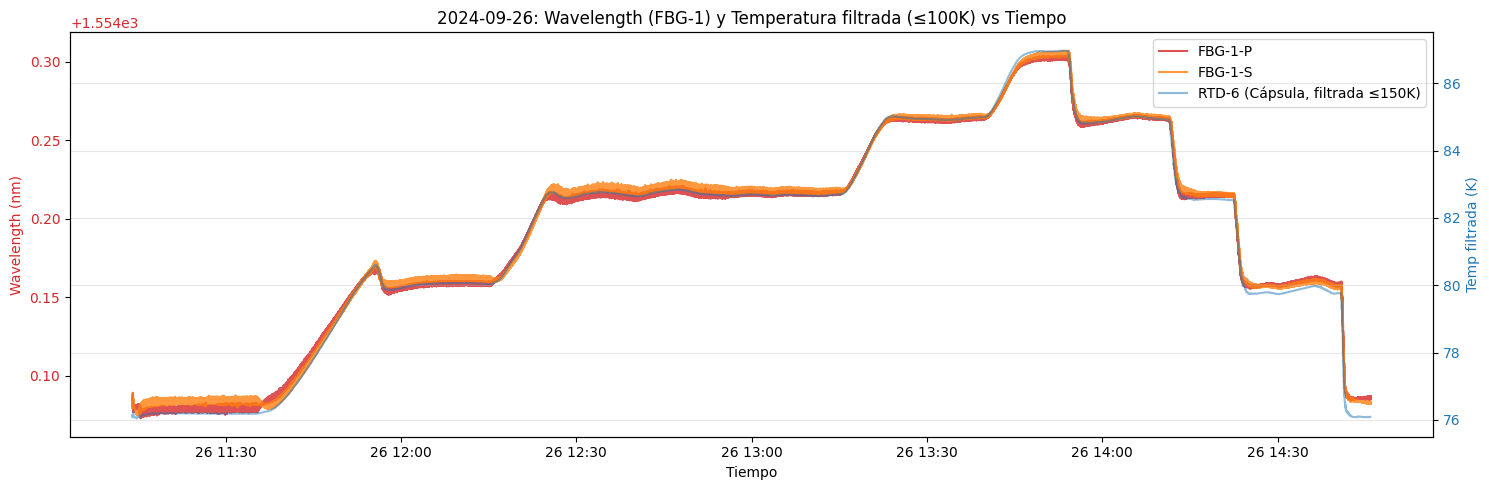

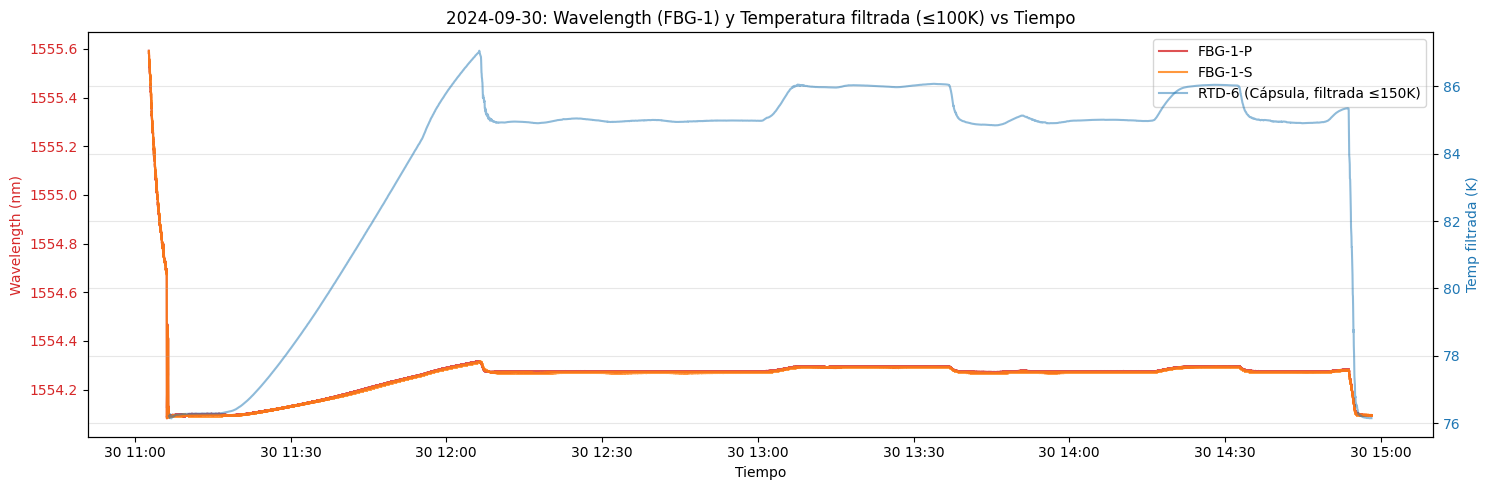

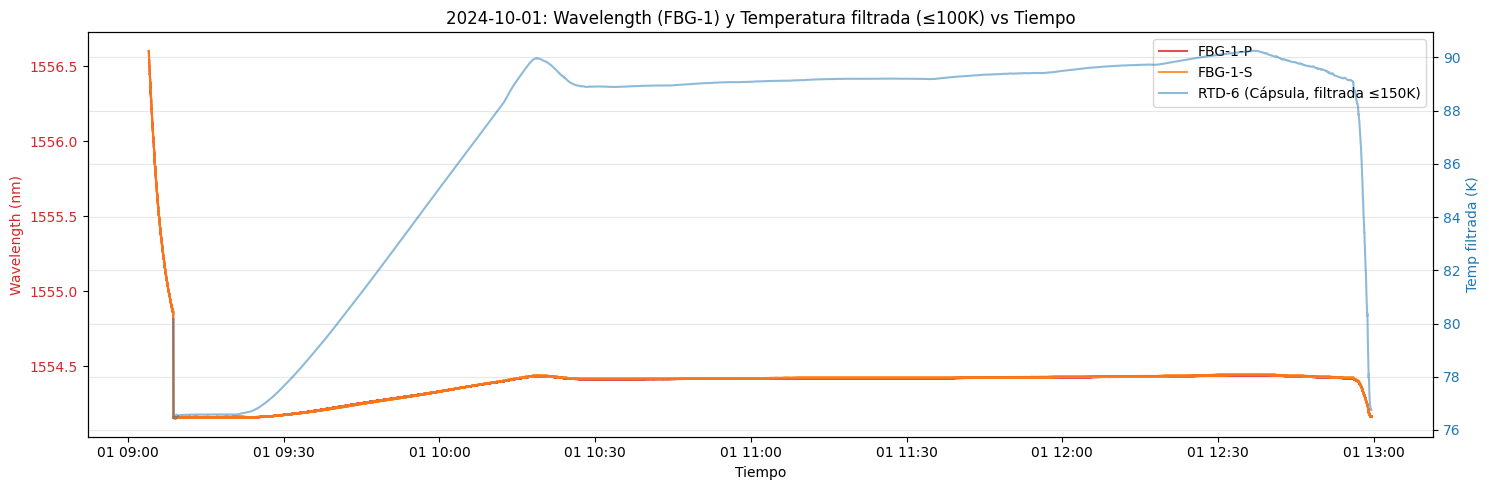

In [6]:
# Visualización para cada archivo: 'wav' (ambas polarizaciones) y 'temp' (RTD cápsula, filtrada a <=100K)
# Eje izquierdo: longitud de onda (nm), eje derecho: temperatura filtrada (K)
for fecha in datos:
    fig, ax1 = plt.subplots(figsize=(15,5))
    wav = datos[fecha]['wav']
    times = np.array(datos[fecha]['times_peak'])
    temp = datos[fecha]['temp_val']
    times_temp = datos[fecha]['times_temp']
    # --- CORRECCIÓN PARA 25-09-2024: usar los valores originales de wav si el filtrado deja todo NaN ---
    if fecha == '2024-09-25':
        peak = datos[fecha]['peak']
        wav_orig = peak['wav']
        if wav_orig.ndim == 3 and wav_orig.shape[2] == 1:
            wav_orig = wav_orig[:,:,0]
        wav_orig_nm = wav_orig * 1e9
        min_len = min(len(times), wav_orig_nm.shape[0])
        wav = wav_orig_nm[:min_len]
        times = times[:min_len]
        # Asegurarse de que wav es 2D
        if wav.ndim == 1:
            wav = wav[:, np.newaxis]
        elif wav.ndim > 2:
            wav = wav.reshape(wav.shape[0], -1)
        if times.ndim > 1:
            times = times.flatten()
    else:
        # Asegurarse de que wav es 2D y times es 1D
        if wav.ndim == 1:
            wav = wav[:, np.newaxis]
        elif wav.ndim > 2:
            wav = wav.reshape(wav.shape[0], -1)
        if times.ndim > 1:
            times = times.flatten()
    # Comprobar dimensiones
    shape = wav.shape
    if len(shape) == 2:
        n_samples, n_pols = shape
    elif len(shape) == 1:
        n_samples = shape[0]
        n_pols = 1
        wav = wav[:, np.newaxis]
    else:
        raise ValueError(f"Forma inesperada de wav: {shape}")
    pol_labels = ['P', 'S']
    colors = ['tab:red', 'tab:orange']
    for idx_pol in range(n_pols):
        pol = pol_labels[idx_pol] if idx_pol < len(pol_labels) else f'Pol{idx_pol}'
        wav_pol = wav[:, idx_pol]
        mask_valid = wav_pol > 0
        # Solo graficar si hay datos válidos y dimensiones coinciden
        if np.sum(mask_valid) > 0 and len(times) == len(wav_pol):
            ax1.plot(times[mask_valid], wav_pol[mask_valid], label=f'FBG-1-{pol}', color=colors[idx_pol%len(colors)], alpha=0.8)
    ax1.set_xlabel('Tiempo')
    ax1.set_ylabel('Wavelength (nm)', color='tab:red')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    # Eje derecho para temperatura filtrada
    if temp.ndim == 2 and temp.shape[1] > 6:
        temp_filt = np.copy(temp[:,6])
        temp_filt[temp_filt > 100] = np.nan
        ax2 = ax1.twinx()
        ax2.plot(times_temp, temp_filt, label='RTD-6 (Cápsula, filtrada ≤150K)', color='tab:blue', alpha=0.5)
        ax2.set_ylabel('Temp filtrada (K)', color='tab:blue')
        ax2.tick_params(axis='y', labelcolor='tab:blue')
    # Leyenda combinada
    lines, labels = ax1.get_legend_handles_labels()
    if temp.ndim == 2 and temp.shape[1] > 6:
        lines2, labels2 = ax2.get_legend_handles_labels()
        lines += lines2
        labels += labels2
    ax1.legend(lines, labels, loc='best')
    plt.title(f"{fecha}: Wavelength (FBG-1) y Temperatura filtrada (≤100K) vs Tiempo")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 5️⃣ Selección provisional de plateaus (editable)
Definimos intervalos provisionales de plateaus para cada archivo y polarización. Estos valores deben editarse manualmente tras inspección visual.

In [7]:
# Intervalos de plateaus definidos manualmente tras inspección
# Formato: {fecha: {polarizacion: [(t_ini, t_fin), ...]}}
plateaus = {
    # '2024-09-25': {  # No se definen plateaus para este día por falta de datos válidos
    #     'P': [],
    #     'S': [],
    # },
    '2024-09-26': {
        'P': [
            (datetime.datetime(2024,9,26,11,20), datetime.datetime(2024,9,26,11,31)),
            (datetime.datetime(2024,9,26,12,0), datetime.datetime(2024,9,26,12,10)),
            (datetime.datetime(2024,9,26,13,0), datetime.datetime(2024,9,26,13,5)),
            (datetime.datetime(2024,9,26,13,28), datetime.datetime(2024,9,26,13,32)),
            (datetime.datetime(2024,9,26,13,50), datetime.datetime(2024,9,26,13,53)),
            (datetime.datetime(2024,9,26,14,0), datetime.datetime(2024,9,26,14,6)),
            (datetime.datetime(2024,9,26,14,14), datetime.datetime(2024,9,26,14,18)),
            (datetime.datetime(2024,9,26,14,30), datetime.datetime(2024,9,26,14,35)),
        ],
        'S': [
            (datetime.datetime(2024,9,26,11,20), datetime.datetime(2024,9,26,11,31)),
            (datetime.datetime(2024,9,26,12,0), datetime.datetime(2024,9,26,12,10)),
            (datetime.datetime(2024,9,26,13,0), datetime.datetime(2024,9,26,13,5)),
            (datetime.datetime(2024,9,26,13,28), datetime.datetime(2024,9,26,13,32)),
            (datetime.datetime(2024,9,26,13,50), datetime.datetime(2024,9,26,13,53)),
            (datetime.datetime(2024,9,26,14,0), datetime.datetime(2024,9,26,14,6)),
            (datetime.datetime(2024,9,26,14,14), datetime.datetime(2024,9,26,14,18)),
            (datetime.datetime(2024,9,26,14,30), datetime.datetime(2024,9,26,14,35)),
        ],
    },
    '2024-09-30': {
        'P': [
            (datetime.datetime(2024,9,30,12,30), datetime.datetime(2024,9,30,12,50)),
            (datetime.datetime(2024,9,30,13,20), datetime.datetime(2024,9,30,13,30)),
            (datetime.datetime(2024,9,30,14,0), datetime.datetime(2024,9,30,14,6)),
            (datetime.datetime(2024,9,30,14,27), datetime.datetime(2024,9,30,14,31)),
            (datetime.datetime(2024,9,30,14,42), datetime.datetime(2024,9,30,14,50)),
        ],
        'S': [
            (datetime.datetime(2024,9,30,12,30), datetime.datetime(2024,9,30,12,50)),
            (datetime.datetime(2024,9,30,13,20), datetime.datetime(2024,9,30,13,30)),
            (datetime.datetime(2024,9,30,14,0), datetime.datetime(2024,9,30,14,6)),
            (datetime.datetime(2024,9,30,14,27), datetime.datetime(2024,9,30,14,31)),
            (datetime.datetime(2024,9,30,14,42), datetime.datetime(2024,9,30,14,50)),
        ],
    },
    '2024-10-01': {
        'P': [
            (datetime.datetime(2024,10,1,9,11), datetime.datetime(2024,10,1,9,17)),
            (datetime.datetime(2024,10,1,11,0), datetime.datetime(2024,10,1,12,0)),
        ],
        'S': [
            (datetime.datetime(2024,10,1,9,11), datetime.datetime(2024,10,1,9,17)),
            (datetime.datetime(2024,10,1,11,0), datetime.datetime(2024,10,1,12,0)),
        ],
    },
}
print("Plateaus definidos manualmente según inspección visual. El 25-09-2024 se omite por falta de datos de 'wav' válidos.")

Plateaus definidos manualmente según inspección visual. El 25-09-2024 se omite por falta de datos de 'wav' válidos.


## 6️⃣ Detección y ajuste (fit) de plateaus para cada archivo
Detectamos los plateaus en los intervalos definidos y ajustamos (fit) los datos de cada plateau para extraer parámetros relevantes.

In [8]:
# Ajuste lineal de cada plateau para cada archivo y polarización (robusto a desajustes de longitud)
resultados_plateaus = {}
for fecha in datos:
    if fecha not in plateaus:
        print(f"⚠️ No hay plateaus definidos para {fecha}, se omite este run.")
        continue
    resultados_plateaus[fecha] = {}
    for pol, idx_pol in zip(['P','S'], [0,1]):
        # Interpolar wav a los tiempos de temperatura
        times_peak = np.array(datos[fecha]['times_peak'])
        if times_peak.ndim == 2:
            times_peak_1d = times_peak[:,0]
        else:
            times_peak_1d = times_peak
        wav = datos[fecha]['wav'][:,idx_pol]
        times_temp = np.array(datos[fecha]['times_temp'])
        temp = datos[fecha]['temp_val'][:,6] if datos[fecha]['temp_val'].shape[1]>6 else np.full_like(times_temp, np.nan)
        mask_valid_wav = ~np.isnan(wav)
        # Robustez: comprobar longitudes antes de indexar
        if len(mask_valid_wav) != len(times_peak_1d):
            print(f"[AVISO] Desajuste de longitudes en {fecha} pol {pol}: len(mask_valid_wav)={len(mask_valid_wav)}, len(times_peak_1d)={len(times_peak_1d)}. No se interpola.")
            wav_interp = np.full_like(times_temp, np.nan)
        elif np.sum(mask_valid_wav) < 2:
            print(f"[AVISO] No hay suficientes datos válidos de wav para interpolar en {fecha} pol {pol}")
            wav_interp = np.full_like(times_temp, np.nan)
        else:
            try:
                wav_interp = np.interp(
                    [t.timestamp() for t in times_temp],
                    [t.timestamp() for t in times_peak_1d[mask_valid_wav]],
                    wav[mask_valid_wav],
                    left=np.nan, right=np.nan
                )
            except Exception as e:
                print(f"[ERROR] Interpolando wav en {fecha} pol {pol}: {e}")
                wav_interp = np.full_like(times_temp, np.nan)
        resultados_plateaus[fecha][pol] = []
        # Usar los plateaus definidos sobre los tiempos de temperatura
        masks = seleccionar_plateaus(times_temp, plateaus[fecha][pol])
        for i_mask, mask in enumerate(masks):
            # Diagnóstico de longitudes
            if len(mask) != len(temp) or len(mask) != len(wav_interp):
                print(f"[DIAGNÓSTICO] Desajuste de longitudes en {fecha} pol {pol} plateau {i_mask+1}:")
                print(f"  len(mask): {len(mask)}  len(temp): {len(temp)}  len(wav_interp): {len(wav_interp)}")
                min_len = min(len(mask), len(temp), len(wav_interp))
                mask = mask[:min_len]
                temp_c = temp[:min_len]
                wav_c = wav_interp[:min_len]
            else:
                temp_c = temp
                wav_c = wav_interp
            try:
                slope, std_err = fit_plateau(temp_c[mask], wav_c[mask])
                resultados_plateaus[fecha][pol].append({'slope': slope, 'std_err': std_err})
            except Exception as e:
                print(f"[ERROR] Fallo en fit_plateau para {fecha} pol {pol} plateau {i_mask+1}: {e}")
                print(f"  mask sum: {np.sum(mask)}  temp_c shape: {temp_c.shape}  wav_c shape: {wav_c.shape}")
                resultados_plateaus[fecha][pol].append({'slope': np.nan, 'std_err': np.nan})
print("Ajuste lineal realizado para cada plateau y polarización (robusto a desajustes de longitud).");


⚠️ No hay plateaus definidos para 2024-09-25, se omite este run.


Ajuste lineal realizado para cada plateau y polarización (robusto a desajustes de longitud).


In [9]:
# For each plateau, print mean temperature and wavelength, but do NOT plot to avoid notebook overload
def media_y_error(x):
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan
    return np.mean(x), np.std(x)/np.sqrt(len(x)) if len(x) > 1 else (np.mean(x), np.nan)

for fecha in datos:
    if fecha not in plateaus:
        continue
    for pol, idx_pol in zip(['P','S'], [0,1]):
        # Plateaus over temperature times
        times_temp = np.array(datos[fecha]['times_temp'])
        temp = datos[fecha]['temp_val'][:,6] if datos[fecha]['temp_val'].shape[1]>6 else np.full_like(times_temp, np.nan)
        masks_temp = seleccionar_plateaus(times_temp, plateaus[fecha][pol])
        # Plateaus over peak times
        times_peak = np.array(datos[fecha]['times_peak'])
        wav = datos[fecha]['wav'][:,idx_pol]
        masks_wav = seleccionar_plateaus(times_peak, plateaus[fecha][pol])
        for i_mask, (mask_t, mask_w) in enumerate(zip(masks_temp, masks_wav)):
            t_mean, t_err = media_y_error(temp[mask_t])
            w_mean, w_err = media_y_error(wav[mask_w])
            print(f"--- {fecha} pol {pol} plateau {i_mask+1} ---")
            print(f"  temp: {t_mean:.3f} ± {t_err:.3g}  wav: {w_mean:.3f} ± {w_err:.3g}")
            # The following plot is commented to avoid notebook overload
            # import matplotlib.pyplot as plt
            # fig, ax1 = plt.subplots(figsize=(7,4))
            # ax1.plot(temp[mask_t], np.full(np.sum(mask_t), w_mean), 'o', label='Temp plateau', color='tab:blue', alpha=0.5)
            # ax1.plot(np.full(np.sum(mask_w), t_mean), wav[mask_w], 'o', label='Wav plateau', color='tab:red', alpha=0.5)
            # ax1.errorbar(t_mean, w_mean, xerr=t_err, yerr=w_err, fmt='s', color='k', label='Mean ± error')
            # ax1.set_xlabel('Temp (K)')
            # ax1.set_ylabel('Wavelength (nm)')
            # ax1.set_title(f'{fecha} {pol} plateau {i_mask+1} (independent means)')
            # ax1.legend()
            # plt.tight_layout()
            # plt.show()


--- 2024-09-26 pol P plateau 1 ---
  temp: 76.190 ± 0.000193  wav: 1554.079 ± 2.54e-06
--- 2024-09-26 pol P plateau 2 ---
  temp: 80.028 ± 0.00253  wav: 1554.158 ± 3.65e-06
--- 2024-09-26 pol P plateau 3 ---
  temp: 82.682 ± 0.00102  wav: 1554.216 ± 2.75e-06
--- 2024-09-26 pol P plateau 4 ---
  temp: 84.940 ± 0.000663  wav: 1554.263 ± 2.22e-06
--- 2024-09-26 pol P plateau 5 ---
  temp: 86.954 ± 0.000617  wav: 1554.302 ± 2.5e-06
--- 2024-09-26 pol P plateau 6 ---
  temp: 84.947 ± 0.00414  wav: 1554.264 ± 5.19e-06
--- 2024-09-26 pol P plateau 7 ---
  temp: 82.561 ± 0.00165  wav: 1554.214 ± 2.47e-06
--- 2024-09-26 pol P plateau 8 ---
  temp: 79.827 ± 0.00521  wav: 1554.159 ± 6.05e-06
--- 2024-09-26 pol S plateau 1 ---
  temp: 76.190 ± 0.000193  wav: 1554.084 ± 2.4e-06
--- 2024-09-26 pol S plateau 2 ---
  temp: 80.028 ± 0.00253  wav: 1554.161 ± 3.64e-06
--- 2024-09-26 pol S plateau 3 ---
  temp: 82.682 ± 0.00102  wav: 1554.218 ± 3.04e-06
--- 2024-09-26 pol S plateau 4 ---
  temp: 84.940 ± 

## 7️⃣ Cálculo de sensibilidad para cada medida y polarización
Calculamos la sensibilidad para cada archivo y cada polarización a partir de los fits realizados en los plateaus.

[2024-09-26 P plateau 1] temp: 76.190±0.000193, wav: 1554.079±2.54e-06
[2024-09-26 P plateau 2] temp: 80.028±0.00253, wav: 1554.158±3.65e-06
[2024-09-26 P plateau 3] temp: 82.682±0.00102, wav: 1554.216±2.75e-06
[2024-09-26 P plateau 4] temp: 84.940±0.000663, wav: 1554.263±2.22e-06
[2024-09-26 P plateau 5] temp: 86.954±0.000617, wav: 1554.302±2.5e-06
[2024-09-26 P plateau 6] temp: 84.947±0.00414, wav: 1554.264±5.19e-06
[2024-09-26 P plateau 7] temp: 82.561±0.00165, wav: 1554.214±2.47e-06
[2024-09-26 P plateau 8] temp: 79.827±0.00521, wav: 1554.159±6.05e-06


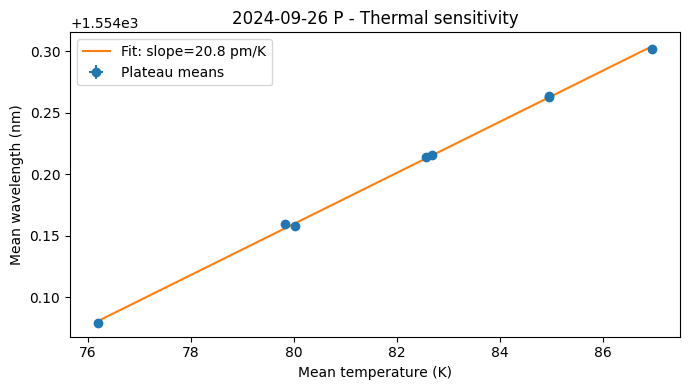

[2024-09-26 S plateau 1] temp: 76.190±0.000193, wav: 1554.084±2.4e-06
[2024-09-26 S plateau 2] temp: 80.028±0.00253, wav: 1554.161±3.64e-06
[2024-09-26 S plateau 3] temp: 82.682±0.00102, wav: 1554.218±3.04e-06
[2024-09-26 S plateau 4] temp: 84.940±0.000663, wav: 1554.264±2.48e-06
[2024-09-26 S plateau 5] temp: 86.954±0.000617, wav: 1554.305±3.12e-06
[2024-09-26 S plateau 6] temp: 84.947±0.00414, wav: 1554.265±4.61e-06
[2024-09-26 S plateau 7] temp: 82.561±0.00165, wav: 1554.216±5.51e-06
[2024-09-26 S plateau 8] temp: 79.827±0.00521, wav: 1554.158±5.65e-06


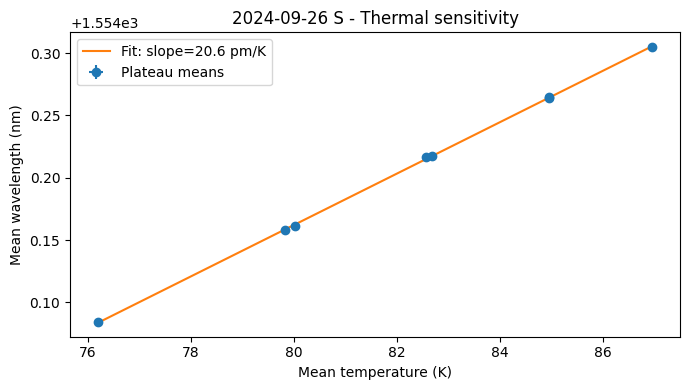

[2024-09-30 P plateau 1] temp: 84.972±0.000764, wav: 1554.274±1.42e-06
[2024-09-30 P plateau 2] temp: 86.005±0.000956, wav: 1554.294±1.79e-06
[2024-09-30 P plateau 3] temp: 84.998±0.000885, wav: 1554.274±2.45e-06
[2024-09-30 P plateau 4] temp: 86.046±0.000381, wav: 1554.295±2.49e-06
[2024-09-30 P plateau 5] temp: 84.929±0.00121, wav: 1554.273±1.87e-06


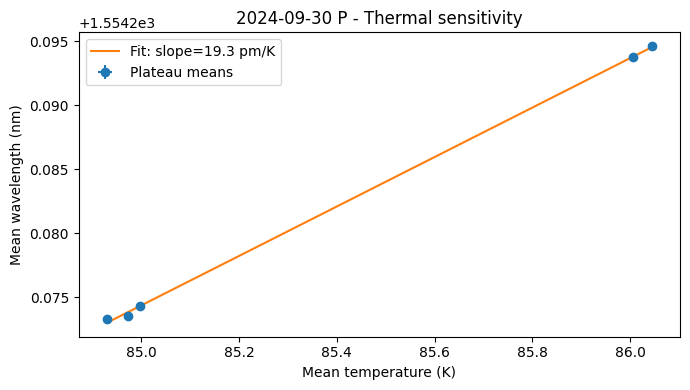

[2024-09-30 S plateau 1] temp: 84.972±0.000764, wav: 1554.269±1.27e-06
[2024-09-30 S plateau 2] temp: 86.005±0.000956, wav: 1554.290±1.8e-06
[2024-09-30 S plateau 3] temp: 84.998±0.000885, wav: 1554.270±2.35e-06
[2024-09-30 S plateau 4] temp: 86.046±0.000381, wav: 1554.292±2.38e-06
[2024-09-30 S plateau 5] temp: 84.929±0.00121, wav: 1554.270±1.93e-06


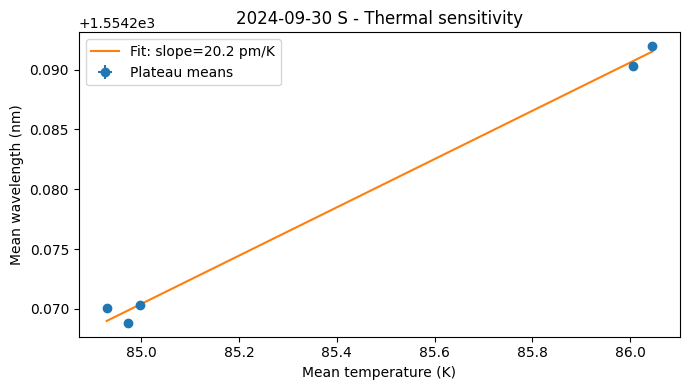

[2024-10-01 P plateau 1] temp: 76.580±0.000287, wav: 1554.160±4.84e-06
[2024-10-01 P plateau 2] temp: 89.247±0.00258, wav: 1554.422±3.2e-06


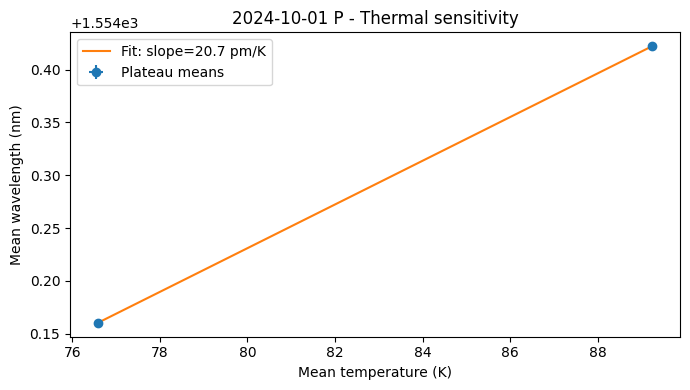

[2024-10-01 S plateau 1] temp: 76.580±0.000287, wav: 1554.161±4.09e-06
[2024-10-01 S plateau 2] temp: 89.247±0.00258, wav: 1554.425±3.42e-06


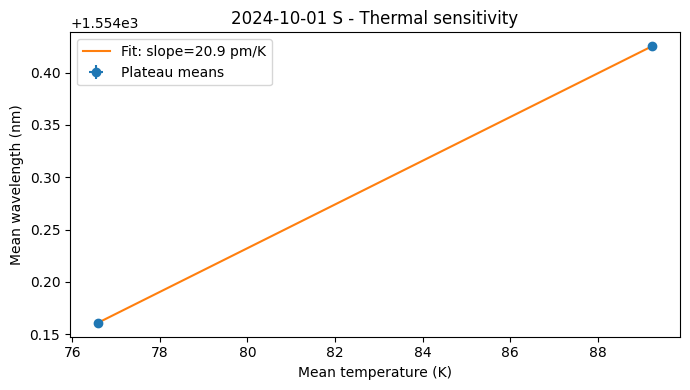

,fecha,polarizacion,slope,std_err
0,2024-09-26,P,0.020785,0.000220
1,2024-09-26,S,0.020622,0.000110
2,2024-09-30,P,0.019323,0.000232
3,2024-09-30,S,0.020193,0.000799
4,2024-10-01,P,0.020669,0.000000
5,2024-10-01,S,0.020875,0.000000


In [10]:
# Global sensitivity: linear fit of means of each plateau (wav_mean vs temp_mean) using independent means per channel, in pm/K
from scipy.stats import linregress

def media_y_error(x):
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan
    return np.mean(x), np.std(x)/np.sqrt(len(x)) if len(x) > 1 else (np.mean(x), np.nan)

sensibilidad_global = []
for fecha in datos:
    if fecha not in plateaus:
        continue
    for pol, idx_pol in zip(['P','S'], [0,1]):
        # Plateaus over temperature times
        times_temp = np.array(datos[fecha]['times_temp'])
        temp = datos[fecha]['temp_val'][:,6] if datos[fecha]['temp_val'].shape[1]>6 else np.full_like(times_temp, np.nan)
        masks_temp = seleccionar_plateaus(times_temp, plateaus[fecha][pol])
        # Plateaus over peak times
        times_peak = np.array(datos[fecha]['times_peak'])
        wav = datos[fecha]['wav'][:,idx_pol]
        masks_wav = seleccionar_plateaus(times_peak, plateaus[fecha][pol])
        temp_medias, temp_errs, wav_medias, wav_errs = [], [], [], []
        for i_mask, (mask_t, mask_w) in enumerate(zip(masks_temp, masks_wav)):
            t_mean, t_err = media_y_error(temp[mask_t])
            w_mean, w_err = media_y_error(wav[mask_w])
            temp_medias.append(t_mean)
            temp_errs.append(t_err)
            wav_medias.append(w_mean)
            wav_errs.append(w_err)
            print(f"[{fecha} {pol} plateau {i_mask+1}] temp: {t_mean:.3f}±{t_err:.3g}, wav: {w_mean:.3f}±{w_err:.3g}")
        temp_medias = np.array(temp_medias)
        wav_medias = np.array(wav_medias)
        temp_errs = np.array(temp_errs)
        wav_errs = np.array(wav_errs)
        mask_valid = ~np.isnan(temp_medias) & ~np.isnan(wav_medias)
        if np.sum(mask_valid) > 1:
            slope, intercept, r, p, std_err = linregress(temp_medias[mask_valid], wav_medias[mask_valid])
            sensibilidad_global.append({'fecha': fecha, 'polarizacion': pol, 'slope': slope, 'std_err': std_err})
            # Plot with error bars, in pm/K
            plt.figure(figsize=(7,4))
            plt.errorbar(temp_medias, wav_medias, xerr=temp_errs, yerr=wav_errs, fmt='o', label='Plateau means')
            xfit = np.linspace(np.nanmin(temp_medias[mask_valid]), np.nanmax(temp_medias[mask_valid]), 50)
            yfit = slope*xfit + intercept
            plt.plot(xfit, yfit, '-', label=f'Fit: slope={slope*1000:.1f} pm/K')
            plt.xlabel('Mean temperature (K)')
            plt.ylabel('Mean wavelength (nm)')
            plt.title(f'{fecha} {pol} - Thermal sensitivity')
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print(f'[WARNING] Not enough valid plateaus for fit in {fecha} {pol}')
# Show summary table of global sensitivities
import pandas as pd
df_sens_global = pd.DataFrame(sensibilidad_global)
display(df_sens_global)


# 8️⃣ Plot de repetibilidad de sensibilidades
Graficamos las sensibilidades obtenidas para las cuatro medidas y ambas polarizaciones, mostrando la repetibilidad.

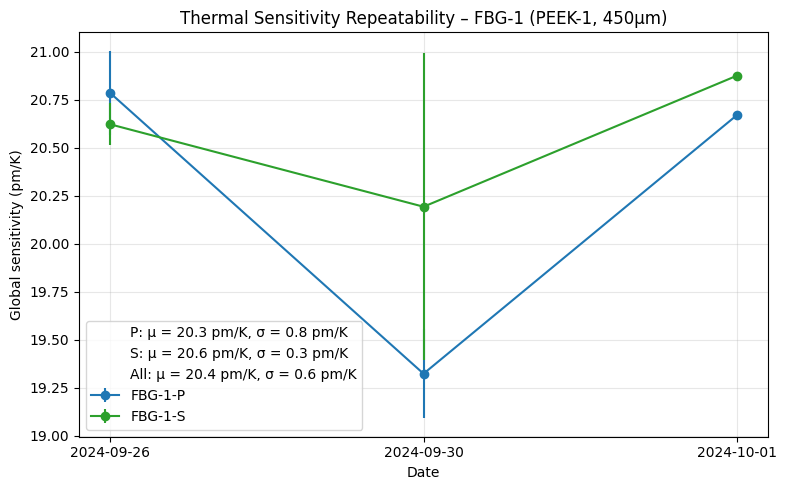

In [11]:
# Plot of global sensitivities for each date and polarization, in pm/K, with combined mean and sigma in legend
plt.figure(figsize=(8,5))
colors = {'P': 'tab:blue', 'S': 'tab:green'}
for pol in ['P','S']:
    df_pol = df_sens_global[df_sens_global['polarizacion']==pol]
    plt.errorbar(df_pol['fecha'], df_pol['slope']*1000, yerr=df_pol['std_err']*1000, fmt='o-', color=colors[pol], label=f'FBG-1-{pol}')
# Calcular media y sigma combinadas para las 6 medidas (P+S)
all_sens = df_sens_global['slope']*1000
mean_all = all_sens.mean()
std_all = all_sens.std(ddof=1) if len(all_sens) > 1 else 0
# Añadir a la leyenda de cada línea
for pol in ['P','S']:
    df_pol = df_sens_global[df_sens_global['polarizacion']==pol]
    mean_pol = (df_pol['slope']*1000).mean()
    std_pol = (df_pol['slope']*1000).std(ddof=1) if len(df_pol['slope']) > 1 else 0
    plt.plot([], [], ' ', label=f"{pol}: μ = {mean_pol:.1f} pm/K, σ = {std_pol:.1f} pm/K")
plt.plot([], [], ' ', label=f"All: μ = {mean_all:.1f} pm/K, σ = {std_all:.1f} pm/K")
plt.xlabel('Date')
plt.ylabel('Global sensitivity (pm/K)')
plt.title('Thermal Sensitivity Repeatability – FBG-1 (PEEK-1, 450μm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9️⃣ Tabla resumen de sensibilidades por archivo y polarización
Tabla resumen con las sensibilidades obtenidas para cada archivo y polarización, lista para exportar o analizar.

In [12]:
# Mostrar tabla resumen de sensibilidades globales (no por plateau)
print("Tabla resumen de sensibilidades globales (nm/K):")
display(df_sens_global)
# Para exportar: df_sens_global.to_csv('sensibilidades_globales_peek1_450um_4dias.csv', index=False)

Tabla resumen de sensibilidades globales (nm/K):


,fecha,polarizacion,slope,std_err
0,2024-09-26,P,0.020785,0.000220
1,2024-09-26,S,0.020622,0.000110
2,2024-09-30,P,0.019323,0.000232
3,2024-09-30,S,0.020193,0.000799
4,2024-10-01,P,0.020669,0.000000
5,2024-10-01,S,0.020875,0.000000
